## Credit Score Classification
### By: Virgie Queena Shallomitha

In [ ]:
import pandas as pd
import numpy as np
import pickle as pkl
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('../pipeline/data/credit_data_raw.csv')

## 1. EDA

In [ ]:
df.head()

,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0,0x15309,CUS_0xaa66,April,NaN,32,841-06-2917,Architect,14995.29,NaN,...,Bad,4593.28,29.968714,3 Years and 2 Months,Yes,60.535964,54.73854091370111,Low_spent_Medium_value_payments,278.586245369556,Poor
1,1,0x8bb6,CUS_0x7d83,January,Dasguptaj,30,227-93-6471,Lawyer,74902.8,6272.900000,...,Bad,2900.49,28.086006,12 Years and 9 Months,Yes,534.751534,52.25901203477476,High_spent_Large_value_payments,280.27945391259857,Poor
2,2,0xe016,CUS_0x71aa,January,Nicholasq,22,632-01-7252,Lawyer,20574.71,1813.559167,...,Bad,2592.78,32.525087,12 Years and 1 Months,Yes,88.759975,77.89308197841973,Low_spent_Large_value_payments,284.70286002007293,Poor
3,3,0xbffb,CUS_0x59b6,February,Scuffhamk,53,315-03-3600,Writer,111090.06,9192.505000,...,Good,575.32,25.360743,27 Years and 6 Months,No,149.079658,436.7372848909153,Low_spent_Medium_value_payments,613.4335567793378,Standard
4,4,0xa96e,CUS_0x36a1,January,Miyoung Kimh,42,286-88-7128,Teacher,19214.965,1730.247083,...,Good,498.81,37.600265,28 Years and 9 Months,No,0.000000,217.7804724472987,!@9#%8,245.2442358860347,Good


In [ ]:
print(df.shape)

(25000, 29)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                25000 non-null  int64  
 1   ID                        25000 non-null  object 
 2   Customer_ID               25000 non-null  object 
 3   Month                     25000 non-null  object 
 4   Name                      22534 non-null  object 
 5   Age                       25000 non-null  object 
 6   SSN                       25000 non-null  object 
 7   Occupation                25000 non-null  object 
 8   Annual_Income             25000 non-null  object 
 9   Monthly_Inhand_Salary     21244 non-null  float64
 10  Num_Bank_Accounts         25000 non-null  int64  
 11  Num_Credit_Card           25000 non-null  int64  
 12  Interest_Rate             25000 non-null  int64  
 13  Num_of_Loan               25000 non-null  object 
 14  Type_o

There are several columns found with the wrong data type as follows:
- Month
- Age
- Annual_Income
- Num_of_Loan
- Type_of_Loan
- Num_of_Delayed_Payment
- Changed_Credit_Limit
- Outstanding_Debt
- Credit_History_Age
- Amount_invested_monthly
- Monthly_Balance

### 1.1 Missing Values

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
ID,0
Customer_ID,0
Month,0
Name,2466
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,3756


Found Missing Values in Name, Monthly_Inhand_Salary, Type_of_Loan, Num_of_Delayed_Payment, Num_Credit_Inquiries, Credit_History_Age, Amount_invested_monthly, Monthly_Balance

### 1.2 Numerical Checks

In [ ]:
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    print(df[col].describe())

count    25000.000000
mean     12499.500000
std       7217.022701
min          0.000000
25%       6249.750000
50%      12499.500000
75%      18749.250000
max      24999.000000
Name: Unnamed: 0, dtype: float64
count    21244.000000
mean      4202.920107
std       3167.562787
min        303.645417
25%       1634.214792
50%       3118.399167
75%       5968.797083
max      15204.633333
Name: Monthly_Inhand_Salary, dtype: float64
count    25000.000000
mean        16.189320
std        113.979946
min         -1.000000
25%          3.000000
50%          6.000000
75%          7.000000
max       1798.000000
Name: Num_Bank_Accounts, dtype: float64
count    25000.000000
mean        22.204800
std        128.635884
min          0.000000
25%          4.000000
50%          5.000000
75%          7.000000
max       1495.000000
Name: Num_Credit_Card, dtype: float64
count    25000.000000
mean        72.883720
std        464.533619
min          1.000000
25%          8.000000
50%         13.000000
75%      

From the numerical check above, there are several columns with illogical values as follows:
1. Num_Bank_Accounts: min -1 (negative number of accounts is impossible), max 1798 (1798 bank accounts is impossible)

2. Num_Credit_Card: max 1495 (impossible number of credit cards + 75th percentile is 7)

3. Interest_Rate: max 5774 (impossible + 75th percentile is 20)

4. Num_Credit_Inquiries: max 2587 (impossible + 75th percentile is 9)

5. Total_EMI_per_month: max 82256  (rare + 75th percentile is 161)

6. Delay_from_due_date: min -5 (may or may not be early pay)


In [ ]:
print(df.duplicated().sum())

0


#### 1.3 Categorical Checks

In [ ]:
for column in df.select_dtypes(include=['object']).columns:
    print(f"Column: {column}")
    print(df[column].value_counts(), end="\n\n")

Column: ID
ID
0x12b25    1
0x15309    1
0x8bb6     1
0xe016     1
0xbffb     1
          ..
0x1b410    1
0x1a54     1
0x9c19     1
0xd2d7     1
0x25275    1
Name: count, Length: 25000, dtype: int64

Column: Customer_ID
Customer_ID
CUS_0xb319    7
CUS_0x6070    7
CUS_0x8c13    7
CUS_0x302f    7
CUS_0xa663    7
             ..
CUS_0xc3cd    1
CUS_0xaea1    1
CUS_0x9a71    1
CUS_0x8c88    1
CUS_0x2eb1    1
Name: count, Length: 11275, dtype: int64

Column: Month
Month
March       3184
July        3175
January     3137
August      3136
April       3122
February    3106
May         3082
June        3058
Name: count, dtype: int64

Column: Name
Name
Nicko              17
Phila              15
Davidc             15
Jessicad           14
Lucia Mutikanip    12
                   ..
Nigelf              1
Leongy              1
Weirf               1
Ajitx               1
Xiaoyi Shaoa        1
Name: count, Length: 9064, dtype: int64

Column: Age
Age
28      755
31      702
22      697
38      696
34 

From the categorical checks above, there are some columns with inconsistencies:

1. ID, Customer_ID, Name, SSN: identifier, no predictive value (dropped later on)

2. Occupation: _______ appears 1792x (imputed with NaN later on)

3. Annual_Income: wrong data type due to underscores (e.g. 41871.96_) + possible outliers (converted & bounded)

4. Num_of_Loan: wrong data type due to underscores (e.g. 1320_) + possible outliers (e.g. 1496) (converted & bounded)

5. Type_of_Loan: comma-separated multi-value text (engineered later on)

6. Num_of_Delayed_Payment: wrong data type + possible outliers (e.g. 3738, 1985) (converted & bounded)

7. Changed_Credit_Limit: wrong data type due to 532 underscores (converted & imputed with NaN)

8. Credit_Mix: wrong data type due to 5172x underscores (converted + imputed with NaN)

9. Credit_History_Age: text format X Years and Y Months (changed to total months)

10. Payment_of_Min_Amount: NM (not mentioned) appears 3082x (imputed with NaN later on)

11. Amount_invested_monthly: wrong data type due to __10000__ appearing 1129x (converted & imputed with NaN)

12. Payment_Behaviour: !@9#%8 appears 1903x (imputed with NaN later on)

13. Monthly_Balance: wrong data type due to __-333...__ appearing 2x (converted & imputed with NaN)


order: Credit_Mix

no order: Occupation, Payment_of_Min_Amount, Payment_Behaviour, Credit_Score

##### 1.5 Modifications before Train Test Split (that doesn't lead to data leakage)

In [ ]:
#Convert String to Numeric Columns
str_num = ['Age', 'Annual_Income', 'Num_of_Loan', 'Num_of_Delayed_Payment','Changed_Credit_Limit', 'Outstanding_Debt', 'Amount_invested_monthly', 'Monthly_Balance']
for col in str_num:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace('_', '', regex=False), errors='coerce')

In [ ]:
#Bound Impossible Values to NaN (imputed later to avoid data leakage)
bounds = {
    'Age': (14, 100),
    'Num_Bank_Accounts': (0, 20),
    'Num_Credit_Card': (0, 20),
    'Interest_Rate': (1, 50),
    'Num_of_Loan': (0, 15),
    'Num_of_Delayed_Payment': (0, 50),
    'Num_Credit_Inquiries': (0, 50)
}
for col, (low, high) in bounds.items():
    df[col] = df[col].where(df[col].between(low, high), np.nan)

In [ ]:
#Replace Placeholders with NaN
df['Occupation'] = df['Occupation'].replace('_______', np.nan)
df['Credit_Mix'] = df['Credit_Mix'].replace('_', np.nan)
df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].replace('NM', np.nan)
df['Payment_Behaviour'] = df['Payment_Behaviour'].replace('!@9#%8', np.nan)

In [ ]:
#Get Months from Credit_History_Age
def get_months(value):
    if pd.isna(value):
        return np.nan
    parts = str(value).split()#'3 Years and 2 Months' -> ['3', 'Years', 'and', '2', 'Months']
    years = int(parts[0])#years
    months = int(parts[3])#months
    return years * 12 + months

df['Credit_History_Age'] = df['Credit_History_Age'].apply(get_months)

In [ ]:
#Count Loan Types from Type_of_Loan
def count_loan_types(value):
    if pd.isna(value) or str(value).strip() == '':
        return 0
    loans = str(value).replace(' and ', ',').split(',')
    return len([loan for loan in loans if loan.strip()])

df['Num_Loan_Types'] = df['Type_of_Loan'].apply(count_loan_types)#engineered feature

In [ ]:
#Mapping Month to Numeric
month_map = {'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
             'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12}
df['Month'] = df['Month'].map(month_map)

In [ ]:
#Drop Identifier + Replaced Columns
df = df.drop(columns=['Unnamed: 0', 'ID', 'Customer_ID', 'Name', 'SSN', 'Type_of_Loan'])#Type_of_Loan replaced by Num_Loan_Types

In [ ]:
#Updated Missing Values (imputed after split)
df.isnull().sum()

,0
Month,0
Age,719
Occupation,1792
Annual_Income,0
Monthly_Inhand_Salary,3756
Num_Bank_Accounts,298
Num_Credit_Card,554
Interest_Rate,524
Num_of_Loan,1105
Delay_from_due_date,0


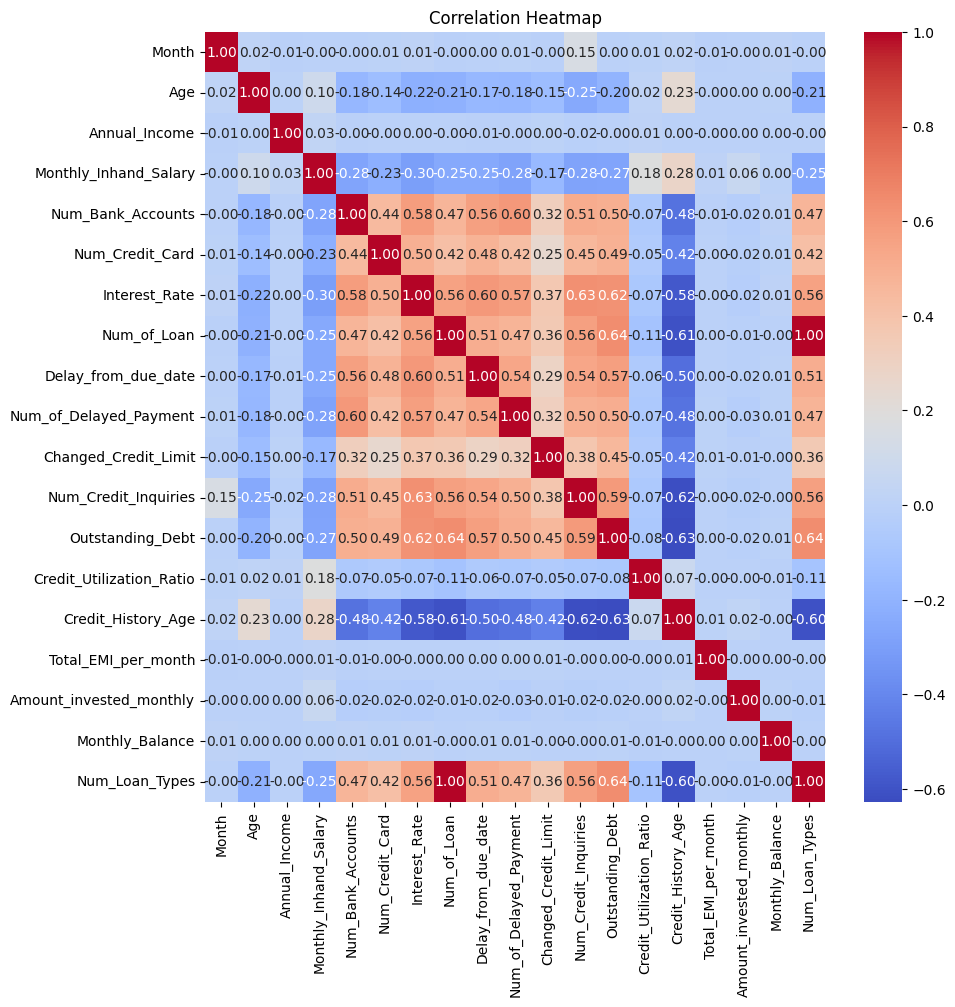

In [ ]:
plt.figure(figsize=(10, 10))
sns.heatmap(x.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

### 2. Train-Test Splitting

In [ ]:
x = df.drop(columns=['Credit_Score'])#features
y = df['Credit_Score']#target

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y,
    test_size=0.2,
    random_state=42,
    stratify=y)

In [ ]:
x_train.shape

(20000, 23)

In [ ]:
x_test.shape

(5000, 23)

### 3. Encoding Target Column

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

In [ ]:
le.classes_

array(['Good', 'Poor', 'Standard'], dtype=object)

In [ ]:
y_train_enc[:5] #Check if encoded

array([2, 2, 2, 1, 1])

In [ ]:
#Get Numerical & Categorical Columns
cat_cols = x_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = x_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [ ]:
num_cols

['Month',
 'Age',
 'Annual_Income',
 'Monthly_Inhand_Salary',
 'Num_Bank_Accounts',
 'Num_Credit_Card',
 'Interest_Rate',
 'Num_of_Loan',
 'Delay_from_due_date',
 'Num_of_Delayed_Payment',
 'Changed_Credit_Limit',
 'Num_Credit_Inquiries',
 'Outstanding_Debt',
 'Credit_Utilization_Ratio',
 'Credit_History_Age',
 'Total_EMI_per_month',
 'Amount_invested_monthly',
 'Monthly_Balance',
 'Num_Loan_Types']

In [ ]:
cat_cols

['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']

### 4. Preprocessing Pipeline

In [ ]:
x_train['Credit_Mix'].value_counts()

,count
Credit_Mix,
Standard,7253
Good,4781
Bad,3794


In [ ]:
#In case we need to impute missing value from numerical & categorical columns
#As well as ordinal encoding for Credit_Mix, except Occupation, Payment_of_Min_Amount, & Payment_Behaviour which uses OHE

#order: Credit_Mix
#no order: Occupation, Payment_of_Min_Amount, Payment_Behaviour

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder

numeric_preprocess = Pipeline([('num_imputer', SimpleImputer(strategy='median')),
                               ('scaler', StandardScaler())])

categorical_preprocess = Pipeline([('cat_imputer', SimpleImputer(strategy='most_frequent')),
                                   ('cat_encoder', OrdinalEncoder(categories=[['Bad', 'Standard', 'Good'],], #Credit_Mix
                                                                 handle_unknown='use_encoded_value', unknown_value=-1))])
ohe_preprocess = Pipeline([
    ('cat_imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [ ]:
from sklearn.compose import ColumnTransformer
preprocess = ColumnTransformer(transformers=[
    ('numPreprocess', numeric_preprocess, num_cols),
    ('ordPreprocess', categorical_preprocess, (['Credit_Mix'])),
    ('ohePreprocess', ohe_preprocess, (['Occupation', 'Payment_of_Min_Amount', 'Payment_Behaviour']))
    ],
    remainder='drop')

In [ ]:
preprocess

ColumnTransformer(transformers=[('numPreprocess',
                                 Pipeline(steps=[('num_imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Month', 'Age', 'Annual_Income',
                                  'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
                                  'Num_Credit_Card', 'Interest_Rate',
                                  'Num_of_Loan', 'Delay_from_due_date',
                                  'Num_of_Delayed_Payment',
                                  'Changed_Credit_Limit',
                                  'Num_Credit_I...
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('cat_encoder',
                                                  OrdinalEncoder(categories=[['Bad',
                                                                              'Standard',
                                                                              'Good']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1))]),
                                 ['Credit_Mix']),
                                ('ohePreprocess',
                                 Pipeline(steps=[('cat_imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Occupation', 'Payment_of_Min_Amount',
                                  'Payment_Behaviour'])])

### 5. Complete Pipeline for Preprocessing and Model

In [ ]:
%pip install catboost

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')

##### COMPARING 5 CLASSIFICATION MODELS

In [ ]:
#Training Function
def train_classifiers(x_train, y_train):
    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1),
        'XGBoost': XGBClassifier(n_estimators=300, random_state=42, eval_metric='mlogloss', tree_method='hist'),
        'LightGBM': LGBMClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1),
        'CatBoost': CatBoostClassifier(iterations=300, auto_class_weights='Balanced', random_state=42, verbose=0)
    }

    trained = {}
    for name, model in models.items():
        c_pred = Pipeline([
            ('preprocessing', preprocess),
            ('classifier', model)
        ])
        #Train Pipeline
        c_pred.fit(x_train, y_train) #same as preprocess.fit_transform(x_train)--> model.fit(transformed_x_train, y_train)
        trained[name] = c_pred

    return trained

### 6. Evaluation Metric (Metrik Evaluasi)

In [ ]:
#Evaluation Function
def evaluate(trained, x_test, y_test, label_names):
    for name, c_pred in trained.items():
        preds = c_pred.predict(x_test)

        print(f'\n{name}')
        print(classification_report(y_test, preds, target_names=label_names))

In [ ]:
# Run Training & Evaluation Functions
trained_c = train_classifiers(x_train, y_train_enc)
evaluate(trained_c, x_test, y_test_enc, label_names=le.classes_)


Logistic Regression
              precision    recall  f1-score   support

        Good       0.47      0.82      0.59       909
        Poor       0.64      0.68      0.66      1440
    Standard       0.79      0.56      0.66      2651

    accuracy                           0.64      5000
   macro avg       0.63      0.69      0.64      5000
weighted avg       0.69      0.64      0.65      5000


Random Forest
              precision    recall  f1-score   support

        Good       0.66      0.64      0.65       909
        Poor       0.77      0.70      0.73      1440
    Standard       0.75      0.79      0.77      2651

    accuracy                           0.74      5000
   macro avg       0.73      0.71      0.72      5000
weighted avg       0.74      0.74      0.74      5000


XGBoost
              precision    recall  f1-score   support

        Good       0.67      0.64      0.66       909
        Poor       0.74      0.71      0.73      1440
    Standard       0.75      0

Dikarenakan dataset sangat tidak seimbang (Standard 2651, Poor 1440, Good 909), saya tidak mengandalkan weighted avg karena metrik tersebut memberi bobot pada setiap kelas berdasarkan jumlah sampelnya. Sama halnya dengan accuracy yang sensitif terhadap data tidak seimbang. Oleh karena itu, macro avg F1 Score dipilih sebagai metrik utama karena memberi bobot yang sama pada setiap kelas tanpa memedulikan ukurannya, sehingga performa pada kelas minoritas Good tetap terwakili secara adil.

---

**English:**

Because the dataset is highly imbalanced (Standard 2,651, Poor 1,440, Good 909), I did not rely on the weighted average, since it weights each class by its number of samples. Accuracy is similarly sensitive to imbalanced data. Therefore, the macro-average F1 score was chosen as the main metric, because it gives every class equal weight regardless of its size, so performance on the minority class Good is still fairly represented.

Pada macro avg F1 Score, Random Forest memperoleh nilai tertinggi sebesar 0.72, diikuti XGBoost dengan nilai yang hampir sama.

Selain itu, Random Forest menunjukkan performa paling seimbang antara precision dan recall di seluruh kelas, sehingga prediksinya tidak berat sebelah pada satu kelas tertentu.

Sebaliknya, LightGBM dan CatBoost mencapai recall lebih tinggi pada kelas minoritas Good sebesar 0.82, tetapi dengan precision yang lebih rendah, sehingga menandakan adanya trade-off precision dan recall yang berbeda.

Logistic Regression sebagai baseline linear memperoleh nilai terendah sekitar 0.64, menunjukkan bahwa hubungan antar fitur tidak dapat dipisahkan secara linear.

Berdasarkan hal tersebut, Random Forest dan XGBoost dipilih sebagai 2 model baseline terbaik yang akan melalui hyperparameter tuning.

---

**English:**

On macro-average F1, Random Forest scored the highest at 0.72, followed closely by XGBoost.

Random Forest also showed the most balanced precision and recall across all classes, so its predictions are not skewed toward any single class.

In contrast, LightGBM and CatBoost reached a higher recall of 0.82 on the minority class Good, but with lower precision, showing a different precision-recall trade-off.

Logistic Regression, as the linear baseline, scored the lowest at about 0.64, showing that the classes cannot be separated linearly by the features.

Based on this, Random Forest and XGBoost were chosen as the 2 best baseline models to go through hyperparameter tuning.

### 7. Best Model Experiments (Eksperimen Model Terbaik)

In [ ]:
#Hyperparameter Tuning (top 2 models: Random Forest & XGBoost)
from sklearn.model_selection import GridSearchCV

#Random Forest tuning
rf_pipe = Pipeline([
    ('preprocessing', preprocess),
    ('classifier', RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1))
])
rf_grid = {
    'classifier__max_depth': [None, 30],
    'classifier__min_samples_leaf': [1, 2, 4]
}
rf_search = GridSearchCV(rf_pipe, rf_grid, scoring='f1_macro', cv=3, n_jobs=-1)
rf_search.fit(x_train, y_train_enc)

print(f"RF best CV macro-F1: {rf_search.best_score_:.4f}")
print(f"RF best params: {rf_search.best_params_}")

RF best CV macro-F1: 0.7089
RF best params: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 2}


In [ ]:
#XGBoost tuning
xgb_pipe = Pipeline([
    ('preprocessing', preprocess),
    ('classifier', XGBClassifier(random_state=42, eval_metric='mlogloss', tree_method='hist'))
])
xgb_grid = {
    'classifier__n_estimators': [300, 500],
    'classifier__max_depth': [6, 8],
    'classifier__learning_rate': [0.1, 0.2]
}
xgb_search = GridSearchCV(xgb_pipe, xgb_grid, scoring='f1_macro', cv=3, n_jobs=-1)
xgb_search.fit(x_train, y_train_enc)

print(f"XGB best CV macro-F1: {xgb_search.best_score_:.4f}")
print(f"XGB best params: {xgb_search.best_params_}")

XGB best CV macro-F1: 0.7009
XGB best params: {'classifier__learning_rate': 0.2, 'classifier__max_depth': 8, 'classifier__n_estimators': 300}


In [ ]:
#Tuned Test Performance
from sklearn.metrics import f1_score

rf_tuned = rf_search.best_estimator_
xgb_tuned = xgb_search.best_estimator_

rf_test_f1 = f1_score(y_test_enc, rf_tuned.predict(x_test), average='macro')
xgb_test_f1 = f1_score(y_test_enc, xgb_tuned.predict(x_test), average='macro')

print(f"Random Forest tuned test macro-F1: {rf_test_f1:.4f}")
print(f"XGBoost tuned test macro-F1: {xgb_test_f1:.4f}")

Random Forest tuned test macro-F1: 0.7188
XGBoost tuned test macro-F1: 0.7212


Dua model terbaik, Random Forest dan XGBoost melalui proses hyperparameter tuning menggunakan GridSearchCV dengan Cross Validation dan macro F1 sebagai acuan.

Setelah tuning, Random Forest hanya meningkat tipis menjadi 0.7188 karena performanya sudah mendekati batas optimal, sedangkan XGBoost meningkat lebih signifikan menjadi 0.7212.

Hal ini menandakan XGBoost memiliki ruang peningkatan yang lebih besar dibandingkan Random Forest.

Berdasarkan hasil tersebut, XGBoost dipilih sebagai model terbaik karena memperoleh macro F1 tertinggi setelah tuning, dan model inilah yang digunakan untuk tahap deployment.

---

**English:**

The two best models, Random Forest and XGBoost, were tuned with GridSearchCV using cross-validation, with macro F1 as the scoring metric.

After tuning, Random Forest improved only slightly to 0.7188, as its performance was already close to its limit, while XGBoost improved more, to 0.7212.

This suggests XGBoost had more room for improvement than Random Forest.

Based on these results, XGBoost was chosen as the best model because it achieved the highest macro F1 after tuning, and this is the model used for deployment.